# Individual Homework Assignment

**Student:** Farkas Martin  
**Theme:** Pizza ratings and sales  
**Files used:** `data_task1_variant2.csv`, `data_task2_variant2.csv`, `data_task3_variant2.csv`

This notebook gives a reproducible statistical analysis for all three assigned tasks. I use a significance level of `alpha = 0.05` throughout unless stated otherwise. The course guideline says the submitted filename should contain the student's full name; the present file is named `assignment.ipynb` because that was the requested workspace target.


In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.oneway import anova_oneway
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True})

alpha = 0.05


## Task 1 - One-way comparison of pizza rating means

The response variable is `Score`, a customer rating on a 0-10 scale. The factor is `Group`, the pizza type. The natural method is one-way ANOVA because the question asks whether more than two independent group means are equal.

Hypotheses:

- `H0`: all five group means are equal.
- `H1`: at least one group mean differs.

The classical ANOVA assumptions are independent observations, approximately normal residuals within groups, and approximately equal group variances. Independence is a design assumption; normality and homogeneity are checked below.


,n,mean,sd,median,min,max
Group,,,,,,
Hawaiian,50,5.7730,1.4769,5.690,2.31,8.78
Margherita,50,5.4680,1.6207,5.560,0.64,8.70
Pepperoni,50,5.5484,1.1613,5.505,3.33,8.64
Quattro Formaggi,50,5.4270,1.6058,5.540,2.40,8.59
Vegetarian,50,5.4034,1.5942,5.260,2.05,10.00


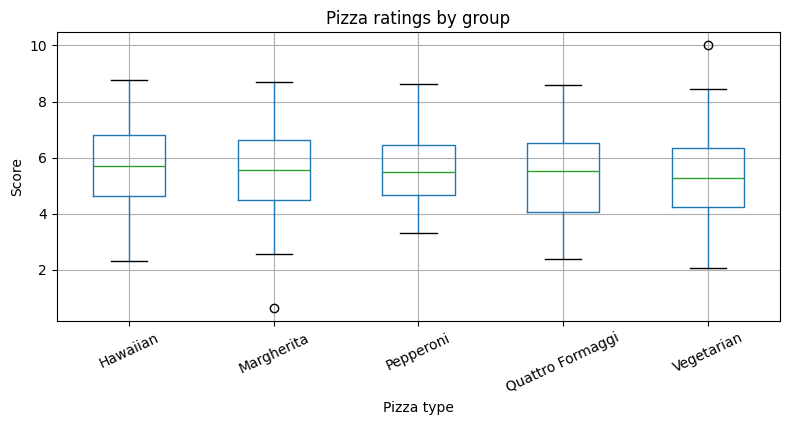

In [2]:
df1 = pd.read_csv("data/data_task1_variant2.csv")
summary1 = (
    df1.groupby("Group")["Score"]
    .agg(n="count", mean="mean", sd="std", median="median", min="min", max="max")
    .sort_index()
)
display(summary1)

fig, ax = plt.subplots()
df1.boxplot(column="Score", by="Group", ax=ax, rot=25)
ax.set_title("Pizza ratings by group")
ax.set_xlabel("Pizza type")
ax.set_ylabel("Score")
plt.suptitle("")
plt.tight_layout()
plt.show()


The sample is balanced: each pizza type has 50 ratings. The group means are all close, ranging from about 5.40 to 5.77, so before formal testing there is no visually dramatic difference. The boxplot supports the same impression: the central locations overlap substantially.


In [3]:
anova_model = smf.ols("Score ~ C(Group)", data=df1).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
display(anova_table)

ss_between = anova_table.loc["C(Group)", "sum_sq"]
ss_within = anova_table.loc["Residual", "sum_sq"]
ss_total = ss_between + ss_within
df_between = anova_table.loc["C(Group)", "df"]
ms_within = anova_table.loc["Residual", "sum_sq"] / anova_table.loc["Residual", "df"]
eta_sq = ss_between / ss_total
omega_sq = max((ss_between - df_between * ms_within) / (ss_total + ms_within), 0)
effect_sizes1 = pd.DataFrame({"effect_size": ["eta-squared", "omega-squared"], "value": [eta_sq, omega_sq]})
display(effect_sizes1)

group_arrays = [g["Score"].to_numpy() for _, g in df1.groupby("Group")]
assumption_checks1 = pd.DataFrame(
    {
        "check": ["Levene test for equal variances", "Shapiro-Wilk test for ANOVA residual normality"],
        "statistic": [
            stats.levene(*group_arrays, center="median").statistic,
            stats.shapiro(anova_model.resid).statistic,
        ],
        "p_value": [
            stats.levene(*group_arrays, center="median").pvalue,
            stats.shapiro(anova_model.resid).pvalue,
        ],
    }
)
display(assumption_checks1)

welch = anova_oneway(group_arrays, use_var="unequal")
print(f"Welch robustness check: F = {welch.statistic:.4f}, df = ({welch.df_num:.0f}, {welch.df_denom:.2f}), p = {welch.pvalue:.4f}")


,sum_sq,df,F,PR(>F)
C(Group),4.4843,4.0,0.4971,0.7379
Residual,552.5469,245.0,NaN,NaN


,effect_size,value
0,eta-squared,0.0081
1,omega-squared,0.0000


,check,statistic,p_value
0,Levene test for equal variances,1.2871,0.2756
1,Shapiro-Wilk test for ANOVA residual normality,0.9960,0.7653


Welch robustness check: F = 0.4815, df = (4, 121.86), p = 0.7493


The ANOVA statistic is `F(4, 245) = 0.4971` with `p = 0.7379`. If the five population means were equal, a between-group signal at least this large would be quite common, so the data do not provide evidence against equal mean ratings. The effect-size estimates are also tiny: eta-squared is about `0.0081`, meaning that pizza type explains less than 1% of the observed rating variability, and omega-squared is truncated to `0.0000`, consistent with no practically meaningful group effect.

The Levene p-value is `0.2756`, so the equal-variance assumption is not contradicted. The Shapiro-Wilk p-value for the ANOVA residuals is `0.7653`, so normality is also plausible. The Welch ANOVA robustness check gives `p = 0.7493`, leading to the same conclusion even without assuming equal variances.


In [4]:
tukey = pairwise_tukeyhsd(endog=df1["Score"], groups=df1["Group"], alpha=alpha)
tukey_table = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
display(tukey_table)


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Hawaiian,Margherita,-0.3050,0.8481,-1.1304,0.5204,False
1,Hawaiian,Pepperoni,-0.2246,0.9449,-1.0500,0.6008,False
2,Hawaiian,Quattro Formaggi,-0.3460,0.7785,-1.1714,0.4794,False
3,Hawaiian,Vegetarian,-0.3696,0.7335,-1.1950,0.4558,False
4,Margherita,Pepperoni,0.0804,0.9989,-0.7450,0.9058,False
5,Margherita,Quattro Formaggi,-0.0410,0.9999,-0.8664,0.7844,False
6,Margherita,Vegetarian,-0.0646,0.9995,-0.8900,0.7608,False
7,Pepperoni,Quattro Formaggi,-0.1214,0.9944,-0.9468,0.7040,False
8,Pepperoni,Vegetarian,-0.1450,0.9889,-0.9704,0.6804,False
9,Quattro Formaggi,Vegetarian,-0.0236,1.0000,-0.8490,0.8018,False


Because the omnibus ANOVA is not significant, post-hoc claims are not warranted. The Tukey table is included as a check: every adjusted p-value is large and every simultaneous confidence interval contains zero. Thus, at the 5% level there is no pair of pizza types for which the mean rating differs detectably in this sample.


## Task 2 - Multiple linear regression for weekly sales

The response is `Y`, weekly number of pizzas sold. The predictors are price `X_1` in HUF and customer rating `X_2`. I fit the linear model

`Y = beta_0 + beta_1 X_1 + beta_2 X_2 + epsilon`,

where the error terms are assumed to have mean zero, constant variance, approximate normality, and independence.


In [5]:
df2 = pd.read_csv("data/data_task2_variant2.csv")
display(df2.describe())

def fit_ols_table(model):
    ci = model.conf_int()
    out = pd.DataFrame({
        "estimate": model.params,
        "std_error": model.bse,
        "t": model.tvalues,
        "p_value": model.pvalues,
        "ci_2.5%": ci[0],
        "ci_97.5%": ci[1],
    })
    return out

X2 = sm.add_constant(df2[["X_1", "X_2"]])
y2 = df2["Y"]
model2 = sm.OLS(y2, X2).fit()

coef_table = fit_ols_table(model2)
std_betas = model2.params[["X_1", "X_2"]] * df2[["X_1", "X_2"]].std() / df2["Y"].std()
coef_table["standardized_beta"] = np.nan
coef_table.loc[["X_1", "X_2"], "standardized_beta"] = std_betas

display(coef_table)
print(f"Fitted model: Y_hat = {model2.params['const']:.4f} + {model2.params['X_1']:.4f}*X_1 + {model2.params['X_2']:.4f}*X_2")


,Y,X_1,X_2
count,50.0000,50.000,50.0000
mean,71.5970,1274.780,4.7872
std,35.1969,305.704,3.0205
min,20.0000,805.000,0.0000
25%,43.9625,977.250,1.6475
50%,66.8750,1339.500,5.4200
75%,103.1000,1491.750,7.0000
max,133.8500,1737.000,9.4200


,estimate,std_error,t,p_value,ci_2.5%,ci_97.5%,standardized_beta
const,-219.5147,79.0509,-2.7769,0.0079,-378.5445,-60.4848,NaN
X_1,0.3041,0.0998,3.0475,0.0038,0.1034,0.5048,2.6413
X_2,-20.1680,10.0994,-1.9969,0.0516,-40.4855,0.1495,-1.7308


Fitted model: Y_hat = -219.5147 + 0.3041*X_1 + -20.1680*X_2


The fitted model is

`Y_hat = -219.5147 + 0.3041 X_1 - 20.1680 X_2`.

Holding rating fixed, a 1 HUF increase in price is associated with about `0.304` more pizzas sold per week. Holding price fixed, a one-point rating increase is associated with about `20.17` fewer pizzas sold. The second sign is not a simple causal statement: below we see that price and rating are almost perfectly positively correlated, so the individual slopes are estimated under severe multicollinearity. The standardized coefficients, `2.641` for price and `-1.731` for rating, show the same instability: they are large and opposite because the two predictors move almost together.

The 95% confidence interval for the intercept is `[-378.54, -60.48]`; this is mainly a mathematical baseline because a pizza with zero price and zero rating is outside the meaningful range of the data. The 95% confidence interval for the price slope is `[0.103, 0.505]`, so conditional on rating the price coefficient is significantly positive at 5%. The 95% confidence interval for the rating slope is `[-40.49, 0.15]`, which just includes zero; equivalently its p-value is about `0.052`, so it is not individually significant at the strict 5% level. This near miss is exactly the pattern expected under severe multicollinearity: the model predicts well jointly, but it has difficulty separating the two individual effects.


In [6]:
new_pizza = pd.DataFrame({"const": [1.0], "X_1": [1500.0], "X_2": [8.5]})
pred = model2.get_prediction(new_pizza).summary_frame(alpha=alpha)
display(pred)


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,65.2065,15.2716,34.4841,95.9289,23.5527,106.8603


For a pizza priced at `1500` HUF with rating `8.5`, the fitted expected weekly sales is `65.21`. The 95% confidence interval for the conditional mean is `[34.48, 95.93]`: it describes uncertainty about the average weekly sales for pizzas with these predictor values. The 95% prediction interval is `[23.55, 106.86]`: it is wider because it includes both mean-estimation uncertainty and the random variation of an individual pizza's weekly sales.


In [7]:
gof2 = pd.DataFrame(
    {
        "quantity": ["R-squared", "Adjusted R-squared", "Residual standard error", "Estimated error variance"],
        "value": [model2.rsquared, model2.rsquared_adj, np.sqrt(model2.mse_resid), model2.mse_resid],
    }
)
display(gof2)
print(f"Overall F test: F({int(model2.df_model)}, {int(model2.df_resid)}) = {model2.fvalue:.4f}, p = {model2.f_pvalue:.4g}")


,quantity,value
0,R-squared,0.8486
1,Adjusted R-squared,0.8422
2,Residual standard error,13.9818
3,Estimated error variance,195.4916


Overall F test: F(2, 47) = 131.7554, p = 5.376e-20


The model explains about `84.9%` of the observed variation in weekly sales. The adjusted value, `84.2%`, is only slightly smaller; it penalizes the addition of predictors and is therefore more honest than raw `R^2` when comparing multiple-regression models with different numbers of predictors. The overall F-test has `p = 5.38e-20`, so the predictors are jointly highly informative about weekly sales. Combining this with the coefficient table gives the individual 5% tests: the intercept is statistically different from zero, the price coefficient is significant, and the rating coefficient is not quite significant once price is already in the model.


,variable,VIF
0,const,1598.2894
1,X_1,233.2502
2,X_2,233.2502


,check,value
0,Residual mean,-1.1944e-11
1,Shapiro-Wilk normality p-value,5.6499e-01
2,Durbin-Watson statistic,2.4147e+00
3,Breusch-Pagan homoscedasticity p-value,6.4217e-01
4,Correlation between X_1 and X_2,9.9785e-01


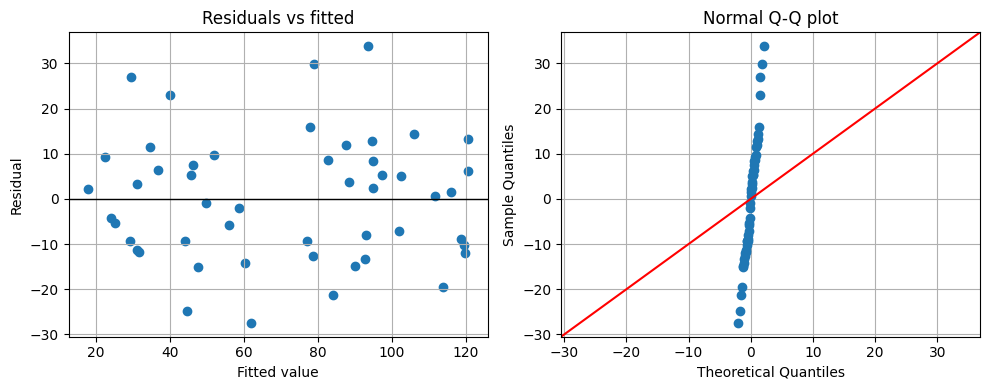

In [8]:
vif_table = pd.DataFrame(
    {
        "variable": X2.columns,
        "VIF": [variance_inflation_factor(X2.to_numpy(), i) for i in range(X2.shape[1])],
    }
)

diagnostic2 = pd.DataFrame(
    {
        "check": [
            "Residual mean",
            "Shapiro-Wilk normality p-value",
            "Durbin-Watson statistic",
            "Breusch-Pagan homoscedasticity p-value",
            "Correlation between X_1 and X_2",
        ],
        "value": [
            model2.resid.mean(),
            stats.shapiro(model2.resid).pvalue,
            durbin_watson(model2.resid),
            het_breuschpagan(model2.resid, X2)[1],
            df2[["X_1", "X_2"]].corr().iloc[0, 1],
        ],
    }
)

display(vif_table)
display(diagnostic2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(model2.fittedvalues, model2.resid)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Fitted value")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs fitted")
sm.qqplot(model2.resid, line="45", ax=axes[1])
axes[1].set_title("Normal Q-Q plot")
plt.tight_layout()
plt.show()


The residual mean is essentially zero, as expected for an OLS model with an intercept. Normality is not rejected (`Shapiro p = 0.565`), the Durbin-Watson statistic is close to 2.4 and does not suggest serious positive autocorrelation, and the Breusch-Pagan p-value (`0.642`) gives no evidence of non-constant variance. The residual plot is reasonably patternless and the Q-Q plot is close to the reference line.

The serious issue is multicollinearity: `corr(X_1, X_2) = 0.9979` and each substantive predictor has `VIF = 233.25` (the intercept VIF is not substantively interpreted). Therefore, the model is excellent for fitted values and prediction inside the observed range, but the individual coefficient interpretations are unstable. The price and rating effects should not be read as clean separate causal effects.


## Task 3 - Introductory time-series modelling

The data are monthly pizza-restaurant sales indexed by `time`. I forecast the next six months (`time = 51, ..., 56`) using three approaches: a deterministic polynomial trend, exponential smoothing, and a Box-Jenkins SARIMA model.


,time,value
0,1,50.0000
1,2,57.1503
2,3,52.9749
3,4,50.1044
4,5,56.8372


,time,value
45,46,180.5324
46,47,181.9937
47,48,196.5031
48,49,193.1628
49,50,200.0000


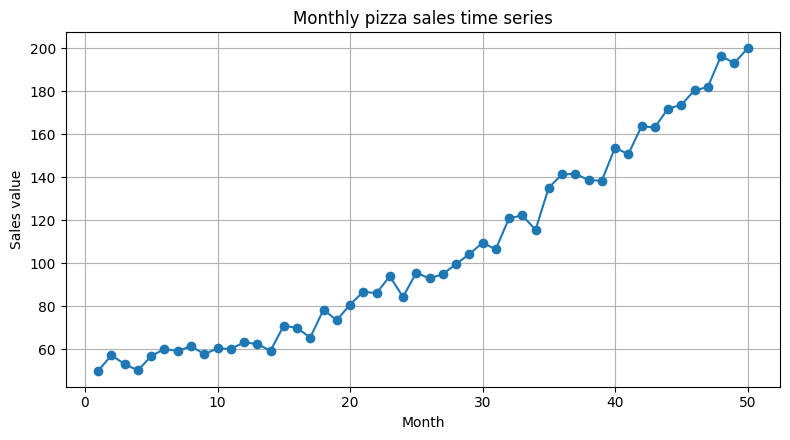

In [9]:
df3 = pd.read_csv("data/data_task3_variant2.csv")
display(df3.head())
display(df3.tail())

fig, ax = plt.subplots()
ax.plot(df3["time"], df3["value"], marker="o")
ax.set_xlabel("Month")
ax.set_ylabel("Sales value")
ax.set_title("Monthly pizza sales time series")
plt.tight_layout()
plt.show()


The series rises strongly and nonlinearly from about 50 to 200. The curvature suggests that a quadratic deterministic trend is a plausible baseline model.


In [10]:
trend_candidates = []
for name, formula in [
    ("linear", "value ~ time"),
    ("quadratic", "value ~ time + I(time**2)"),
    ("cubic", "value ~ time + I(time**2) + I(time**3)"),
]:
    m = smf.ols(formula, df3).fit()
    trend_candidates.append({"model": name, "AIC": m.aic, "BIC": m.bic, "adj_R2": m.rsquared_adj})
trend_candidates = pd.DataFrame(trend_candidates)
display(trend_candidates)

trend_model = smf.ols("value ~ time + I(time**2)", df3).fit()
display(fit_ols_table(trend_model))

future = pd.DataFrame({"time": np.arange(51, 57)})
trend_forecast = trend_model.get_prediction(future).summary_frame(alpha=alpha)
trend_forecast.insert(0, "time", future["time"].to_numpy())
display(trend_forecast)

trend_lb = acorr_ljungbox(trend_model.resid, lags=[6, 12], return_df=True)
trend_diag = pd.DataFrame(
    {
        "check": [
            "Residual mean",
            "Estimated error variance",
            "Shapiro p-value",
            "Durbin-Watson",
            "Ljung-Box p-value lag 6",
            "Ljung-Box p-value lag 12",
            "Breusch-Pagan p-value",
        ],
        "value": [
            trend_model.resid.mean(),
            trend_model.mse_resid,
            stats.shapiro(trend_model.resid).pvalue,
            durbin_watson(trend_model.resid),
            trend_lb.loc[6, "lb_pvalue"],
            trend_lb.loc[12, "lb_pvalue"],
            het_breuschpagan(
                trend_model.resid,
                sm.add_constant(pd.DataFrame({"time": df3["time"], "time2": df3["time"] ** 2})),
            )[1],
        ],
    }
)
display(trend_diag)


,model,AIC,BIC,adj_R2
0,linear,386.7573,390.5813,0.9387
1,quadratic,288.9766,294.7127,0.9915
2,cubic,290.5768,298.2248,0.9914


,estimate,std_error,t,p_value,ci_2.5%,ci_97.5%
Intercept,52.5320,1.8681,28.1209,4.7458e-31,48.7739,56.2901
time,0.2174,0.1690,1.2863,2.0462e-01,-0.1226,0.5573
I(time ** 2),0.0555,0.0032,17.2848,5.3316e-22,0.0491,0.0620


,time,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,51,208.0293,1.8681,204.2712,211.7874,198.7301,217.3284
1,52,213.9654,2.0202,209.9012,218.0295,204.5384,223.3924
2,53,220.0125,2.1805,215.6259,224.3990,210.4421,229.5829
3,54,226.1707,2.3487,221.4458,230.8956,216.4405,235.9008
4,55,232.4399,2.5246,227.3611,237.5187,222.5331,242.3467
5,56,238.8201,2.7080,233.3724,244.2679,228.7192,248.9211


,check,value
0,Residual mean,-1.6271e-13
1,Estimated error variance,1.7877e+01
2,Shapiro p-value,7.5235e-01
3,Durbin-Watson,2.3169e+00
4,Ljung-Box p-value lag 6,5.1092e-01
5,Ljung-Box p-value lag 12,3.7524e-01
6,Breusch-Pagan p-value,1.1215e-01


The quadratic trend has much smaller AIC/BIC than the linear trend, while the cubic term does not improve AIC. The selected deterministic model is

`value_hat = 52.5320 + 0.2174 time + 0.0555 time^2`.

The quadratic coefficient is highly significant, confirming accelerating growth. The linear coefficient is not significant once the quadratic term is present, but I keep it because the polynomial hierarchy makes the quadratic trend interpretable. The residual diagnostics are acceptable: the residual mean is zero, normality is plausible (`p = 0.752`), Durbin-Watson is close to 2.32, Ljung-Box p-values at lags 6 and 12 are above 5%, and Breusch-Pagan does not reject constant variance (`p = 0.112`). The deterministic forecasts for months 51-56 range from about `208.03` to `238.82`.


In [11]:
y3 = df3["value"].to_numpy()

es_model_specs = [
    ("simple exponential smoothing", lambda: SimpleExpSmoothing(y3, initialization_method="estimated").fit(optimized=True)),
    ("Holt additive trend", lambda: Holt(y3, initialization_method="estimated").fit(optimized=True)),
    ("Holt damped trend", lambda: Holt(y3, damped_trend=True, initialization_method="estimated").fit(optimized=True)),
    ("Holt-Winters additive trend + additive seasonality", lambda: ExponentialSmoothing(y3, trend="add", seasonal="add", seasonal_periods=12, initialization_method="estimated").fit(optimized=True)),
]

es_models = []
for name, fitfun in es_model_specs:
    fit = fitfun()
    resid = y3 - fit.fittedvalues
    es_models.append(
        {
            "model": name,
            "AIC": fit.aic,
            "SSE": fit.sse,
            "MAE": np.mean(np.abs(resid)),
            "RMSE": np.sqrt(np.mean(resid**2)),
            "fit": fit,
        }
    )

es_compare = pd.DataFrame([{k: v for k, v in row.items() if k != "fit"} for row in es_models]).sort_values("AIC")
display(es_compare)

es_fit = min(es_models, key=lambda row: row["AIC"])["fit"]
es_resid = y3 - es_fit.fittedvalues
es_forecast = pd.DataFrame({"time": np.arange(51, 57), "forecast": es_fit.forecast(6)})
display(es_forecast)

es_params = pd.Series(es_fit.params).drop(labels=["initial_seasons"], errors="ignore")
display(es_params.to_frame("value"))

es_diag = pd.DataFrame(
    {
        "check": ["Residual mean", "Shapiro p-value", "Durbin-Watson", "Ljung-Box p-value lag 6", "Ljung-Box p-value lag 12"],
        "value": [
            es_resid.mean(),
            stats.shapiro(es_resid).pvalue,
            durbin_watson(es_resid),
            acorr_ljungbox(es_resid, lags=[6, 12], return_df=True).loc[6, "lb_pvalue"],
            acorr_ljungbox(es_resid, lags=[6, 12], return_df=True).loc[12, "lb_pvalue"],
        ],
    }
)
display(es_diag)


,model,AIC,SSE,MAE,RMSE
1,Holt additive trend,170.3796,1286.4148,4.1456,5.0723
2,Holt damped trend,173.2411,1308.7737,4.1618,5.1162
3,Holt-Winters additive trend + additive seasona...,179.0613,946.9518,3.4318,4.3519
0,simple exponential smoothing,197.9473,2418.6598,5.2939,6.9551


,time,forecast
0,51,205.1689
1,52,210.2918
2,53,215.4147
3,54,220.5376
4,55,225.6605
5,56,230.7834


,value
smoothing_level,0.2574
smoothing_trend,0.2574
smoothing_seasonal,NaN
damping_trend,NaN
initial_level,51.4094
initial_trend,0.7693
use_boxcox,False
lamda,None
remove_bias,False


,check,value
0,Residual mean,1.3139
1,Shapiro p-value,0.8073
2,Durbin-Watson,2.0882
3,Ljung-Box p-value lag 6,0.6260
4,Ljung-Box p-value lag 12,0.4346


Among the exponential-smoothing candidates, AIC selects Holt's additive trend model. The seasonal Holt-Winters version has smaller raw SSE, but it uses many seasonal initial states; with only 50 observations, AIC penalizes that complexity. Holt's fitted smoothing parameters are about `0.257` for the level and `0.257` for the trend, so the model updates both components meaningfully as new data arrive.

The residual diagnostics for Holt's method are acceptable: normality is plausible (`p = 0.807`), Durbin-Watson is close to 2.09, and the Ljung-Box tests at lags 6 and 12 do not find residual autocorrelation. The six forecasts increase from about `205.17` to `230.78`.


In [12]:
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

arima_specs = [
    ("ARIMA(0,2,1)", (0, 2, 1), (0, 0, 0, 0), 2),
    ("ARIMA(1,2,1)", (1, 2, 1), (0, 0, 0, 0), 2),
    ("ARIMA(2,2,0)", (2, 2, 0), (0, 0, 0, 0), 2),
    ("SARIMA(0,1,1)(0,1,1)[12]", (0, 1, 1), (0, 1, 1, 12), 13),
    ("SARIMA(1,1,0)(0,1,1)[12]", (1, 1, 0), (0, 1, 1, 12), 13),
]

arima_rows = []
fitted_arima = {}
for name, order, seasonal_order, burn in arima_specs:
    fit = ARIMA(y3, order=order, seasonal_order=seasonal_order, trend="n").fit()
    fitted_arima[name] = (fit, burn)
    resid = fit.resid[burn:]
    lb = acorr_ljungbox(resid, lags=[6, 12], return_df=True)
    arima_rows.append(
        {
            "model": name,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "converged": fit.mle_retvals.get("converged", True),
            "Shapiro_p_after_burn": stats.shapiro(resid).pvalue,
            "LjungBox_p_lag6": lb.loc[6, "lb_pvalue"],
            "LjungBox_p_lag12": lb.loc[12, "lb_pvalue"],
        }
    )

arima_compare = pd.DataFrame(arima_rows).sort_values("AIC")
display(arima_compare)

sarima_fit, burn = fitted_arima["SARIMA(0,1,1)(0,1,1)[12]"]
param_table = pd.DataFrame(
    {
        "estimate": sarima_fit.params,
        "p_value": sarima_fit.pvalues,
    },
    index=sarima_fit.param_names,
)
display(param_table)

sarima_resid = sarima_fit.resid[burn:]
sarima_diag = pd.DataFrame(
    {
        "check": ["Residual mean after burn-in", "Shapiro p-value", "Durbin-Watson", "Ljung-Box p-value lag 6", "Ljung-Box p-value lag 12"],
        "value": [
            sarima_resid.mean(),
            stats.shapiro(sarima_resid).pvalue,
            durbin_watson(sarima_resid),
            acorr_ljungbox(sarima_resid, lags=[6, 12], return_df=True).loc[6, "lb_pvalue"],
            acorr_ljungbox(sarima_resid, lags=[6, 12], return_df=True).loc[12, "lb_pvalue"],
        ],
    }
)
display(sarima_diag)

sarima_forecast = sarima_fit.get_forecast(steps=6).summary_frame(alpha=alpha)
sarima_forecast.insert(0, "time", np.arange(51, 57))
display(sarima_forecast)


,model,AIC,BIC,converged,Shapiro_p_after_burn,LjungBox_p_lag6,LjungBox_p_lag12
4,"SARIMA(1,1,0)(0,1,1)[12]",257.6477,262.4804,True,0.5967,0.2394,0.1057
3,"SARIMA(0,1,1)(0,1,1)[12]",257.7180,262.5507,True,0.5671,0.3752,0.1103
1,"ARIMA(1,2,1)",311.4031,317.0167,True,0.6104,0.3820,0.3222
0,"ARIMA(0,2,1)",323.9700,327.7124,True,0.2502,0.0139,0.0032
2,"ARIMA(2,2,0)",325.3326,330.9462,True,0.9929,0.0867,0.2483


,estimate,p_value
ma.L1,-0.4555,0.0178
ma.S.L12,-0.4319,0.0680
sigma2,49.0305,0.0015


,check,value
0,Residual mean after burn-in,3.0646
1,Shapiro p-value,0.5671
2,Durbin-Watson,2.1603
3,Ljung-Box p-value lag 6,0.3752
4,Ljung-Box p-value lag 12,0.1103


y,time,mean,mean_se,mean_ci_lower,mean_ci_upper
0,51,197.6236,7.0061,183.8918,211.3554
1,52,207.2735,7.9772,191.6384,222.9085
2,53,206.6085,8.8422,189.2781,223.9390
3,54,217.0676,9.6299,198.1933,235.9418
4,55,215.3682,10.3578,195.0672,235.6691
5,56,224.9631,11.0378,203.3293,246.5969


For the Box-Jenkins part I compared a few low-order differenced ARIMA models and simple seasonal alternatives. The best AIC values are obtained by seasonal models, which is reasonable for monthly data. I select `SARIMA(0,1,1)(0,1,1)[12]` as a parsimonious seasonal model; its AIC is essentially tied with `SARIMA(1,1,0)(0,1,1)[12]`, and it uses an interpretable moving-average correction after nonseasonal and seasonal differencing.

The nonseasonal MA coefficient is significant at 5% (`p = 0.0178`), while the seasonal MA coefficient is only borderline (`p = 0.0680`). After removing the first differencing/seasonal initialization residuals, the residual diagnostics are satisfactory: Shapiro `p = 0.567`, Durbin-Watson is about `2.16`, and Ljung-Box p-values at lags 6 and 12 are above 5%. The SARIMA forecasts for months 51-56 range from about `197.62` to `224.96`, with wider uncertainty than the deterministic trend because this model treats the future innovations stochastically.


,time,deterministic_quadratic,holt_additive_trend,sarima
0,51,208.0293,205.1689,197.6236
1,52,213.9654,210.2918,207.2735
2,53,220.0125,215.4147,206.6085
3,54,226.1707,220.5376,217.0676
4,55,232.4399,225.6605,215.3682
5,56,238.8201,230.7834,224.9631


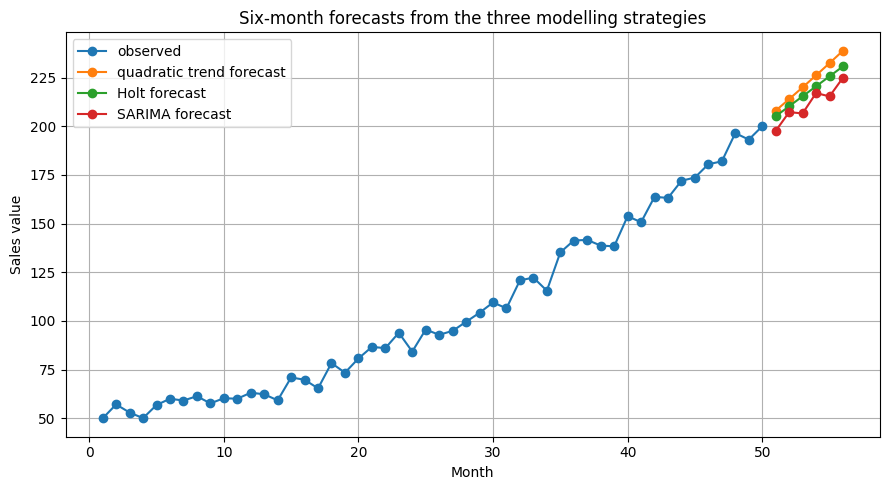

In [13]:
combined_forecasts = pd.DataFrame(
    {
        "time": np.arange(51, 57),
        "deterministic_quadratic": trend_forecast["mean"].to_numpy(),
        "holt_additive_trend": es_forecast["forecast"].to_numpy(),
        "sarima": sarima_forecast["mean"].to_numpy(),
    }
)
display(combined_forecasts)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df3["time"], df3["value"], marker="o", label="observed")
ax.plot(combined_forecasts["time"], combined_forecasts["deterministic_quadratic"], marker="o", label="quadratic trend forecast")
ax.plot(combined_forecasts["time"], combined_forecasts["holt_additive_trend"], marker="o", label="Holt forecast")
ax.plot(combined_forecasts["time"], combined_forecasts["sarima"], marker="o", label="SARIMA forecast")
ax.set_xlabel("Month")
ax.set_ylabel("Sales value")
ax.set_title("Six-month forecasts from the three modelling strategies")
ax.legend()
plt.tight_layout()
plt.show()


The three methods agree on continued growth, but they differ in extrapolation strength. The quadratic deterministic model extrapolates the accelerating trend most aggressively. Holt's trend model gives a middle forecast path. The SARIMA model is more conservative because seasonal differencing makes it rely strongly on past month-to-month and year-to-year changes. For a short academic exercise I would report all three, but if I had to choose a single operational forecast from these diagnostics, I would prefer Holt's additive trend model: it has clean residual diagnostics, avoids the deterministic model's strong quadratic extrapolation assumption, and is less parameter-heavy than the seasonal alternatives.
